In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point

import climattr as eea

plt.rcParams.update({'font.size': 14})

In [5]:
df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
df['year'] = df['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

df = df.groupby(['city_residency', 'year']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
df['dengue_inc'] = 1e5 * df['n_cases'] / df['population']

df['rank'] = df.groupby(['city_residency'])['dengue_inc'].rank(method='dense', ascending=False)

# Filter data for years before 2023
df_before_2023 = df[df['year'] < 2023]

# Method 1: Direct approach - find cities with max incidence <= 300
cities_max_incidence = df_before_2023.groupby('city_residency')['dengue_inc'].max()
cities_no_high_incidence = cities_max_incidence[cities_max_incidence <= 300].index.tolist()

df = df[df['year'] == 2024]

gdf = gpd.read_file('../dengue_attribution/utils/municipios/municipios.shp')
gdf['city_residency'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

region = gpd.read_file('../dengue_attribution/utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')

gdf = eea.impacts.geolocate_dataframe(df, gdf, 'city_residency', 'city_residency')
gdf['log_inc'] = np.log10(gdf['dengue_inc'])

gdf_citys = gdf[gdf['city_residency'].isin(cities_no_high_incidence) & (gdf['dengue_inc'] > 300)]
gdf_citys['state_residency'] = gdf_citys['city_residency'].apply(lambda x: x.split('_')[0])
gdf_citys = gdf_citys[gdf_citys['state_residency'].isin(['RS', 'SC', 'PR'])]

gdf_citys

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_14905/3513999658.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/opt/anaconda3/envs/impact-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/impact-env/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,city_residency,year,n_cases,population,dengue_inc,rank,geometry,log_inc,state_residency
3915,PR_ALMIRANTE TAMANDARE,2024.0,374.0,120041.0,311.560217,1.0,"POLYGON ((-49.25401 -25.31913, -49.25402 -25.3...",2.493542,PR
3930,PR_ARAPOTI,2024.0,992.0,28300.0,3505.300353,1.0,"POLYGON ((-49.76651 -24.04716, -49.76188 -24.0...",3.544725,PR
3933,PR_ARAUCARIA,2024.0,538.0,146214.0,367.953821,1.0,"POLYGON ((-49.39665 -25.77259, -49.39725 -25.7...",2.565793,PR
3949,PR_BOA VENTURA DE SAO ROQUE,2024.0,24.0,6365.0,377.062058,1.0,"POLYGON ((-51.48347 -24.89402, -51.48446 -24.8...",2.576413,PR
3952,PR_BOM JESUS DO SUL,2024.0,62.0,3506.0,1768.397034,1.0,"POLYGON ((-53.60845 -26.21366, -53.60949 -26.2...",3.247580,PR
...,...,...,...,...,...,...,...,...,...
5099,RS_VISTA ALEGRE,2024.0,431.0,2739.0,15735.669953,1.0,"POLYGON ((-53.54431 -27.29729, -53.54449 -27.2...",4.196885,RS
5101,RS_VISTA GAUCHA,2024.0,584.0,2855.0,20455.341506,1.0,"POLYGON ((-53.70393 -27.30702, -53.70482 -27.3...",4.310807,RS
5102,RS_VITORIA DAS MISSOES,2024.0,122.0,3092.0,3945.666235,1.0,"POLYGON ((-54.44172 -28.33886, -54.43306 -28.3...",3.596120,RS
5103,RS_WESTFALIA,2024.0,13.0,3031.0,428.901353,1.0,"POLYGON ((-51.78123 -29.44686, -51.78123 -29.4...",2.632357,RS


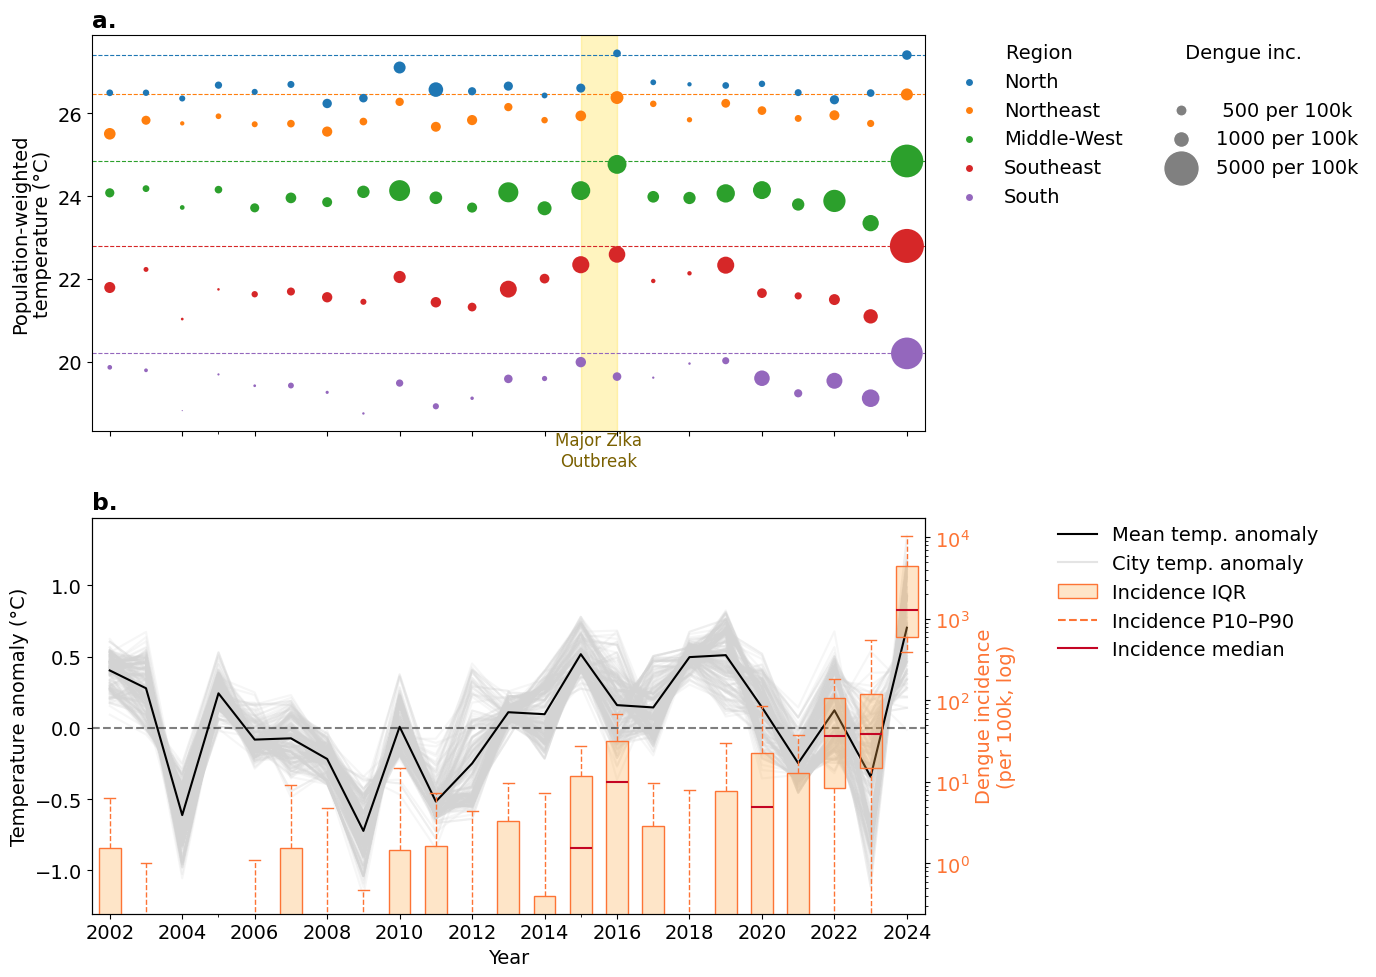

In [6]:
# Load full dataset for the AnnualCases panel
df_all = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv',
                     parse_dates=['date_first_symptoms'], low_memory=False)

wm = lambda x: np.average(x, weights=df_all.loc[x.index, 'population'])

df_regional_monthly = df_all.groupby(['region', 'year', 'date_first_symptoms']).agg(
    n_cases    = ('n_cases',                  'sum'),
    population = ('population',               'sum'),
    temp_mean  = ('mean_2m_air_temp_degree1',  wm),
).reset_index()

df_annual_all = df_regional_monthly.groupby(['region', 'year']).agg(
    n_cases    = ('n_cases',    'sum'),
    population = ('population', 'mean'),
    temp_mean  = ('temp_mean',  'mean'),
).reset_index()
df_annual_all['dengue_inc'] = 1e5 * df_annual_all['n_cases'] / df_annual_all['population']

# ── Figure layout: stacked, shared x ────────────────────────────────────────
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ── Panel A: AnnualCases ─────────────────────────────────────────────────────
regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
scaling = 600
size_max = df_annual_all['dengue_inc'].max()

for region, color in zip(regions, colors):
    df_r = df_annual_all[df_annual_all['region'] == region].sort_values('year')
    ax_a.scatter(df_r['year'], df_r['temp_mean'],
                 s=df_r['dengue_inc'] / size_max * scaling,
                 color=color, label=region, zorder=3,
                 edgecolors='white', linewidths=0.)
    row_2024 = df_r[df_r['year'] == 2024]
    if len(row_2024):
        ax_a.axhline(row_2024.iloc[0]['temp_mean'], color=color, ls='--', lw=0.8)

ax_a.axvspan(2015, 2016, color='gold', alpha=0.25, zorder=0)
ax_a.text(2015.5, ax_a.get_ylim()[0], 'Major Zika\nOutbreak',
          ha='center', va='top', fontsize=12, color='#7a6000')

legend_a = [
    *[plt.scatter([], [], color=c, edgecolors='white', label=r) for c, r in zip(colors, regions)],
    Patch(visible=False, label=''),
    plt.scatter([], [], s= 500/size_max*scaling, color='grey', edgecolors='white', label=' 500 per 100k'),
    plt.scatter([], [], s=1000/size_max*scaling, color='grey', edgecolors='white', label='1000 per 100k'),
    plt.scatter([], [], s=5000/size_max*scaling, color='grey', edgecolors='white', label='5000 per 100k'),
]
ax_a.legend(handles=legend_a, ncols=2, frameon=False,
            bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
            title='Region                  Dengue inc.')
ax_a.set_ylabel('Population-weighted\ntemperature (°C)')
ax_a.set_title('a.', loc='left', fontweight='bold')

# ── Panel B: Temperature anomaly + incidence boxplots (South cities) ─────────
c_p10  = cm.YlOrRd(0.25)
c_mean = cm.YlOrRd(0.55)
c_p90  = cm.YlOrRd(0.85)

ax_b2 = ax_b.twinx()

df_temp = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv',
                      parse_dates=['date_first_symptoms'], low_memory=False)
df_temp = df_temp[df_temp['city_residency'].isin(gdf_citys['city_residency'])][
    ['date_first_symptoms', 'city_residency', 'mean_2m_air_temp_degree1', 'n_cases', 'population']
].copy()

df_temp['month'] = df_temp['date_first_symptoms'].dt.month

# Baseline climatology: monthly mean per city using years before 2023
baseline = (
    df_temp[df_temp['date_first_symptoms'].dt.year < 2023]
    .groupby(['city_residency', 'month'])['mean_2m_air_temp_degree1']
    .mean()
    .rename('temp_baseline')
)

df_temp = df_temp.merge(baseline.reset_index(), on=['city_residency', 'month'])
df_temp['temp_anomaly'] = df_temp['mean_2m_air_temp_degree1'] - df_temp['temp_baseline']
df_temp['year'] = df_temp['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)


df_temp_annual = df_temp.groupby(['year', 'city_residency']).agg(
    temp_anomaly=('temp_anomaly', 'mean'),
    n_cases=('n_cases', 'sum'),
    population=('population', 'mean')
).reset_index()
df_temp_annual['dengue_inc'] = 1e5 * df_temp_annual['n_cases'] / df_temp_annual['population']

anomaly_wide = df_temp_annual.pivot(index='year', columns='city_residency', values='temp_anomaly')
mean_anomaly = anomaly_wide.mean(axis=1)

anomaly_wide.plot(ax=ax_b, color='lightgrey', legend=False, alpha=0.2, zorder=2)
mean_anomaly.plot(ax=ax_b, color='k', legend=False, zorder=3)
ax_b.axhline(0, color='k', linestyle='--', alpha=0.5, zorder=3)
ax_b.set_xlabel('Year')
ax_b.set_ylabel('Temperature anomaly (°C)')

years_b = sorted(df_temp_annual['year'].unique())
inc_by_year_b = [df_temp_annual[df_temp_annual['year'] == y]['dengue_inc'].values for y in years_b]

ax_b2.boxplot(
    inc_by_year_b,
    positions=years_b,
    widths=0.6,
    whis=[10, 90],
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=(*cm.YlOrRd(0.4)[:3], 0.3), edgecolor=c_mean, linewidth=1),
    medianprops=dict(color=c_p90, linewidth=1.5),
    whiskerprops=dict(color=c_mean, linewidth=1, linestyle='--'),
    capprops=dict(color=c_mean, linewidth=1),
)
ax_b2.set_yscale('log')
ax_b2.set_ylabel('Dengue incidence\n(per 100k, log)', color=c_mean)
ax_b2.tick_params(axis='y', labelcolor=c_mean)
ax_b2.set_zorder(ax_b.get_zorder() + 1)
ax_b2.patch.set_visible(False)

legend_b = [
    Line2D([0], [0], color='k',         label='Mean temp. anomaly'),
    Line2D([0], [0], color='lightgrey', alpha=0.6, label='City temp. anomaly'),
    Patch(facecolor=(*cm.YlOrRd(0.4)[:3], 0.3), edgecolor=c_mean, label='Incidence IQR'),
    Line2D([0], [0], color=c_mean, linestyle='--', label='Incidence P10–P90'),
    Line2D([0], [0], color=c_p90, linewidth=1.5,   label='Incidence median'),
]
ax_b.legend(handles=legend_b, frameon=False,
            bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0)
ax_b.set_title('b.', loc='left', fontweight='bold')

# Shared x-axis ticks
ax_b.set_xticks(list(range(2002, 2025, 2)))
ax_b.set_xticklabels(list(range(2002, 2025, 2)))
#ax_b.tick_params(axis='x')

plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.savefig('img/annual_temp_cases_combined.png', bbox_inches='tight', dpi=300)
plt.show()
